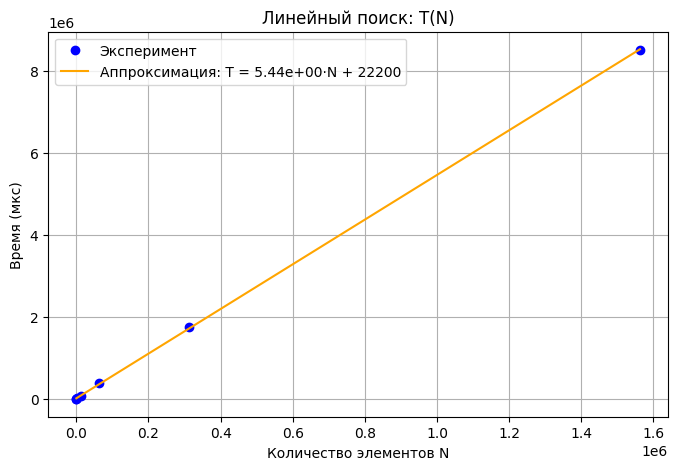

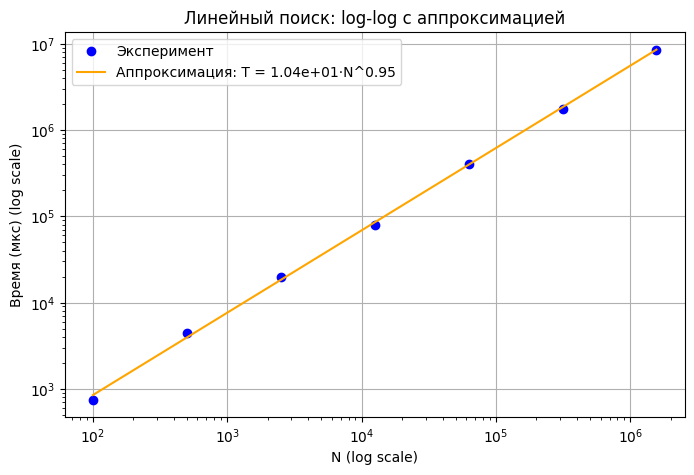

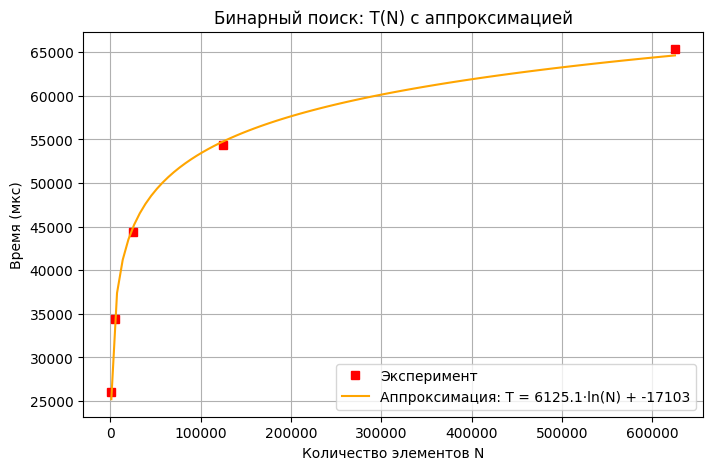

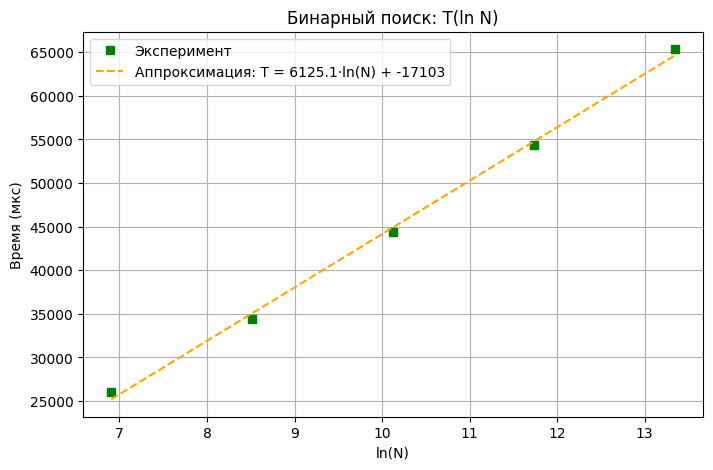

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Данные для линейного поиска
N_linear = [100, 500, 2500, 12500, 62500, 312500, 1562500]
time_linear = [750, 4380, 19930, 79930, 406640, 1754180, 8512590]


# Данные для бинарного поиска
N_binary = [1000, 5000, 25000, 125000, 625000]
time_binary = [26050, 34440, 44360, 54420, 65350]

# ---- График 1: Линейный поиск T(N) в обычном масштабе ----
plt.figure(1, figsize=(8, 5))
# Точки (без линий)
plt.plot(N_linear, time_linear, 'o', color='blue', label='Эксперимент')
# Линейная аппроксимация T = a*N + b
coeffs_lin = np.polyfit(N_linear, time_linear, 1)
trend_lin = np.poly1d(coeffs_lin)
N_fit = np.linspace(min(N_linear), max(N_linear), 100)
plt.plot(N_fit, trend_lin(N_fit), '-', color='orange',
         label=f'Аппроксимация: T = {coeffs_lin[0]:.2e}·N + {coeffs_lin[1]:.0f}')
plt.xlabel('Количество элементов N')
plt.ylabel('Время (мкс)')
plt.title('Линейный поиск: T(N)')
plt.grid(True)
plt.legend()
plt.savefig('linear_T(N)_v3.png')
plt.show()

# ---- График 2: Линейный поиск в логарифмическом масштабе (log-log) ----
plt.figure(2, figsize=(8, 5))
# Точки в лог-лог масштабе (без линий)
plt.loglog(N_linear, time_linear, 'o', color='blue', label='Эксперимент')
# Аппроксимация степенной функцией: T = a * N^b -> линейная регрессия в log-log
logN = np.log(N_linear)
logT = np.log(time_linear)
coeffs_log = np.polyfit(logN, logT, 1)  # коэффициент при logN — показатель степени
a = np.exp(coeffs_log[1])               # коэффициент a в T = a * N^b
b = coeffs_log[0]
# Построим прямую в log-log координатах
N_fit_log = np.logspace(np.log10(min(N_linear)), np.log10(max(N_linear)), 100)
T_fit_log = a * (N_fit_log ** b)
plt.loglog(N_fit_log, T_fit_log, '-', color='orange',
           label=f'Аппроксимация: T = {a:.2e}·N^{b:.2f}')
plt.xlabel('N (log scale)')
plt.ylabel('Время (мкс) (log scale)')
plt.title('Линейный поиск: log-log с аппроксимацией')
plt.grid(True)
plt.legend()
plt.savefig('linear_loglog_v3.png')
plt.show()

# ---- График 3: Бинарный поиск T(N) в обычном масштабе ----
plt.figure(3, figsize=(8, 5))
# Точки (без линий)
plt.plot(N_binary, time_binary, 's', color='red', label='Эксперимент')
# Аппроксимация T = a*ln(N) + b (теоретическая зависимость бинарного поиска)
logN_binary = np.log(N_binary)
coeffs_bin = np.polyfit(logN_binary, time_binary, 1)
trend_bin = np.poly1d(coeffs_bin)
N_fit_bin = np.linspace(min(N_binary), max(N_binary), 100)
plt.plot(N_fit_bin, coeffs_bin[0] * np.log(N_fit_bin) + coeffs_bin[1], '-',
         color='orange', label=f'Аппроксимация: T = {coeffs_bin[0]:.1f}·ln(N) + {coeffs_bin[1]:.0f}')
plt.xlabel('Количество элементов N')
plt.ylabel('Время (мкс)')
plt.title('Бинарный поиск: T(N) с аппроксимацией')
plt.grid(True)
plt.legend()
plt.savefig('binary_T(N)_v3.png')
plt.show()

# ---- График 4: Бинарный поиск T(ln N) ----
plt.figure(4, figsize=(8, 5))
# Точки (без линий)
plt.plot(logN_binary, time_binary, 's', color='green', label='Эксперимент')
# Линейная аппроксимация (уже рассчитана)
plt.plot(logN_binary, trend_bin(logN_binary), '--', color='orange',
         label=f'Аппроксимация: T = {coeffs_bin[0]:.1f}·ln(N) + {coeffs_bin[1]:.0f}')
plt.xlabel('ln(N)')
plt.ylabel('Время (мкс)')
plt.title('Бинарный поиск: T(ln N)')
plt.grid(True)
plt.legend()
plt.savefig('binary_T(lnN)_v3.png')
plt.show()

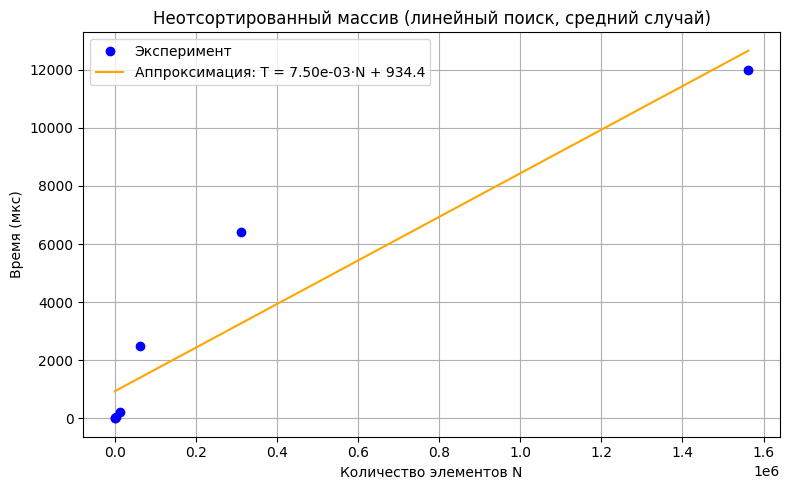

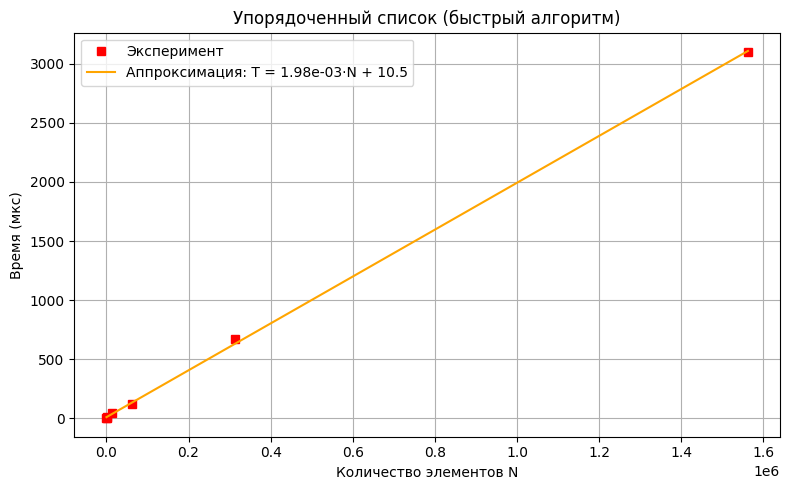

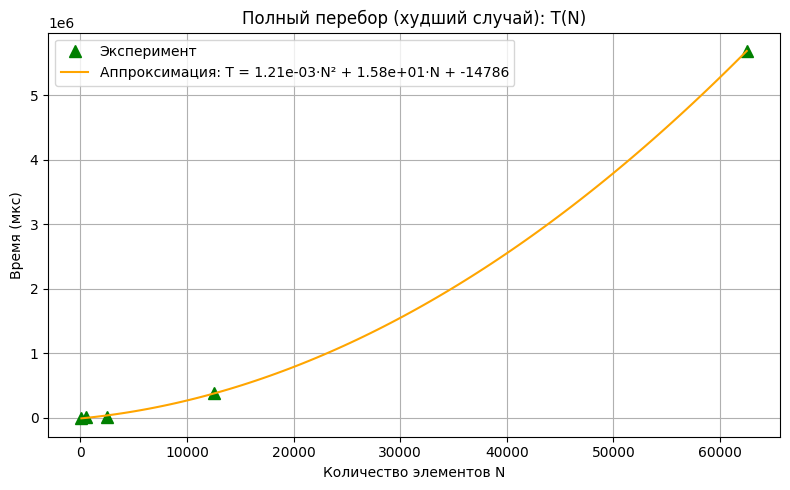

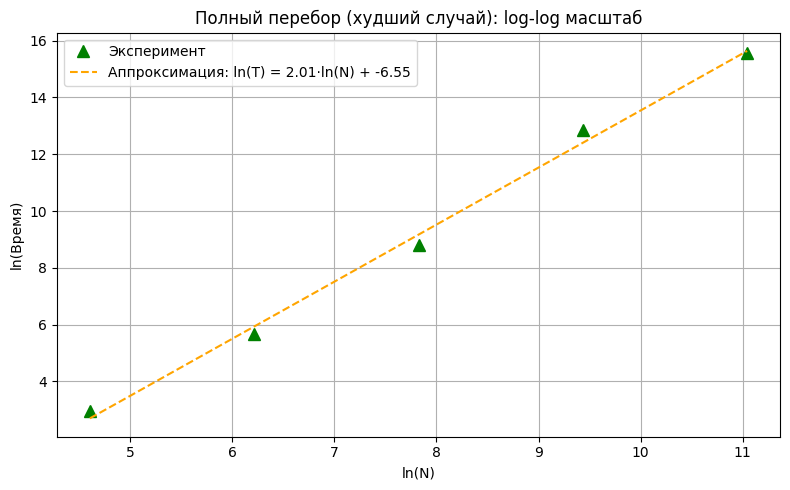

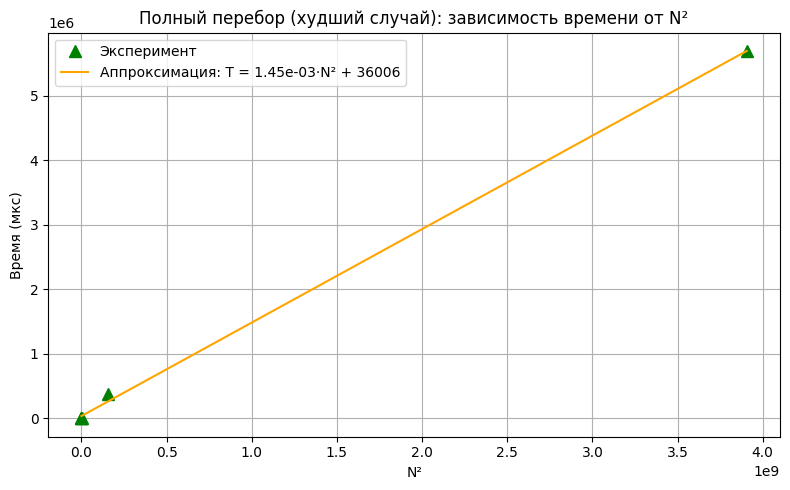

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Данные
N_common = [100, 500, 2500, 12500, 62500, 312500, 1562500]
time_unsorted_avg = [1.28, 7.364, 53.399, 226.989, 2483.89, 6428.16, 11989.5]       # неотсортированный средний
time_sorted = [0.444, 2.148, 7.715, 44.873, 118.45, 670.979, 3099.77]                # упорядоченный

N_worst = [100, 500, 2500, 12500, 62500]
time_unsorted_worst = [19.466, 290.279, 6759.69, 377320, 5.69142e+06]                 # полный перебор худший

# ------------------ График 1: Неотсортированный (средний) ------------------
plt.figure(figsize=(8,5))
# Точки (без линий)
plt.plot(N_common, time_unsorted_avg, 'o', color='blue', markersize=6, label='Эксперимент')
# Линейная аппроксимация T = a*N + b
coeffs_lin = np.polyfit(N_common, time_unsorted_avg, 1)
trend_lin = np.poly1d(coeffs_lin)
N_fit = np.linspace(min(N_common), max(N_common), 100)
plt.plot(N_fit, trend_lin(N_fit), '-', color='orange',
         label=f'Аппроксимация: T = {coeffs_lin[0]:.2e}·N + {coeffs_lin[1]:.1f}')
plt.xlabel('Количество элементов N')
plt.ylabel('Время (мкс)')
plt.title('Неотсортированный массив (линейный поиск, средний случай)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('unsorted_avg_T(N).png')
plt.show()

# ------------------ График 2: Упорядоченный список ------------------
plt.figure(figsize=(8,5))
# Точки (без линий)
plt.plot(N_common, time_sorted, 's', color='red', markersize=6, label='Эксперимент')
# Линейная аппроксимация (предполагаем тоже линейную зависимость)
coeffs_sorted = np.polyfit(N_common, time_sorted, 1)
trend_sorted = np.poly1d(coeffs_sorted)
plt.plot(N_fit, trend_sorted(N_fit), '-', color='orange',
         label=f'Аппроксимация: T = {coeffs_sorted[0]:.2e}·N + {coeffs_sorted[1]:.1f}')
plt.xlabel('Количество элементов N')
plt.ylabel('Время (мкс)')
plt.title('Упорядоченный список (быстрый алгоритм)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('sorted_T(N).png')
plt.show()

# ------------------ График 3: Полный перебор (худший случай) T(N) ------------------
plt.figure(figsize=(8,5))
# Точки (без линий)
plt.plot(N_worst, time_unsorted_worst, '^', color='green', markersize=8, label='Эксперимент')
# Квадратичная аппроксимация T = a*N^2 + b*N + c
coeffs_quad = np.polyfit(N_worst, time_unsorted_worst, 2)
trend_quad = np.poly1d(coeffs_quad)
N_fit_worst = np.linspace(min(N_worst), max(N_worst), 100)
plt.plot(N_fit_worst, trend_quad(N_fit_worst), '-', color='orange',
         label=f'Аппроксимация: T = {coeffs_quad[0]:.2e}·N² + {coeffs_quad[1]:.2e}·N + {coeffs_quad[2]:.0f}')
plt.xlabel('Количество элементов N')
plt.ylabel('Время (мкс)')
plt.title('Полный перебор (худший случай): T(N)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('worst_T(N).png')
plt.show()

# ------------------ График 4: Полный перебор (худший случай) в логарифмическом масштабе ------------------
logN_worst = np.log(N_worst)
logT_worst = np.log(time_unsorted_worst)

plt.figure(figsize=(8,5))
# Точки (без линий)
plt.plot(logN_worst, logT_worst, '^', color='green', markersize=8, label='Эксперимент')
# Линейная аппроксимация в лог-лог координатах (степенная зависимость)
coeff_log = np.polyfit(logN_worst, logT_worst, 1)
log_fit = np.poly1d(coeff_log)
plt.plot(logN_worst, log_fit(logN_worst), '--', color='orange',
         label=f'Аппроксимация: ln(T) = {coeff_log[0]:.2f}·ln(N) + {coeff_log[1]:.2f}')
plt.xlabel('ln(N)')
plt.ylabel('ln(Время)')
plt.title('Полный перебор (худший случай): log-log масштаб')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('worst_loglog.png')
plt.show()

# ------------------ График 5: Полный перебор (худший случай) T(N²) ------------------
N_worst_sq = np.array(N_worst) ** 2
plt.figure(figsize=(8,5))
# Точки (без линий)
plt.plot(N_worst_sq, time_unsorted_worst, '^', color='green', markersize=8, label='Эксперимент')
# Линейная аппроксимация T = a*(N²) + b
coeffs_N2 = np.polyfit(N_worst_sq, time_unsorted_worst, 1)
trend_N2 = np.poly1d(coeffs_N2)
N2_fit = np.linspace(min(N_worst_sq), max(N_worst_sq), 100)
plt.plot(N2_fit, trend_N2(N2_fit), '-', color='orange',
         label=f'Аппроксимация: T = {coeffs_N2[0]:.2e}·N² + {coeffs_N2[1]:.0f}')
plt.xlabel('N²')
plt.ylabel('Время (мкс)')
plt.title('Полный перебор (худший случай): зависимость времени от N²')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('worst_T(N2).png')
plt.show()
